Importo librerias que serviran para hacer el trabajo. El enviroment usa el mismo requirements.txt que el trabajo anterior, pero añadiendo requests,matplotlib y seaborn


In [35]:
#llamar librerias
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import requests
import os
import urllib.request, json, csv
from tqdm import tqdm_notebook as tqdm
import datetime
import dateutil.parser
import unicodedata
import time

Paso 1:

Deseo quedarme con la lista de concursos que ocurrieron entre julio y diciembre de 2024. Para ello es necesario usar el endpoint contest.list de la api de codeforces. Nos quedaremos con una lista en la que estara el ID, nombre y tiempo de inicio de cada concurso.

In [ ]:
import requests
from datetime import datetime

# Creo objeto con fechas limite
start_date = 1719792000 # 1 julio 2024
end_date = 1735689599    # 31 diciembre 2024

# Api lista de concursos
url = "https://codeforces.com/api/contest.list"
response = requests.get(url)
data = response.json()

# Filtrar concursos  entre las fechas dadas
contests = []
for contest in data['result']:
    if (
        'startTimeSeconds' in contest
        and start_date <= contest['startTimeSeconds'] <= end_date
    ):
        contests.append({
            'id': contest['id'],
            'name': contest['name'],
            'start_time': datetime.utcfromtimestamp(contest['startTimeSeconds']).strftime('%Y-%m-%d %H:%M:%S')
        })

# comprobar
for c in contests:
    print(c)

{'id': 2053, 'name': 'Good Bye 2024: 2025 is NEAR', 'start_time': '2024-12-28 14:35:00'}
{'id': 2043, 'name': 'Educational Codeforces Round 173 (Rated for Div. 2)', 'start_time': '2024-12-24 14:35:00'}
{'id': 2054, 'name': 'MaraTON Challenge 1', 'start_time': '2024-12-23 13:35:00'}
{'id': 2051, 'name': 'Codeforces Round 995 (Div. 3)', 'start_time': '2024-12-22 14:35:00'}
{'id': 2049, 'name': 'Codeforces Round 994 (Div. 2)', 'start_time': '2024-12-20 14:35:00'}
{'id': 2048, 'name': 'Codeforces Global Round 28', 'start_time': '2024-12-19 14:35:00'}
{'id': 2044, 'name': 'Codeforces Round 993 (Div. 4)', 'start_time': '2024-12-15 14:35:00'}
{'id': 2052, 'name': '2024-2025 ICPC, NERC, Northern Eurasia Finals (Unrated, Online Mirror, ICPC Rules, Teams Preferred)', 'start_time': '2024-12-15 07:35:00'}
{'id': 2040, 'name': 'Codeforces Round 992 (Div. 2)', 'start_time': '2024-12-08 14:35:00'}
{'id': 2050, 'name': 'Codeforces Round 991 (Div. 3)', 'start_time': '2024-12-05 14:35:00'}
{'id': 2046, 

Paso 2:

Ahora deseo tener informacion sobre cada concursante que participó en los concursos elegidos. Para ello usare el endpoint contest.standings. Ello nos dara una lista en la que habra el ID y nombre del concurso, el handle (nombre) de cada participante, su rank global y los puntos que obtuvieron en cada concurso. Al tenerlo lo pasamos a un dataframe. 

In [ ]:
import requests
import time
import pandas as pd



# Lista donde vamos a guardar los datos de cada participante
rows = []
all_handles = set()

for contest in contests:
    contest_id = contest["id"]
    contest_name = contest["name"]
    
    print(f"Descargando standings del concurso {contest_name} (ID: {contest_id})...")
    
    start = 1
    batch_size = 10000
    while True:
        url = f"https://codeforces.com/api/contest.standings?contestId={contest_id}&from={start}&count={batch_size}"
        response = requests.get(url)
        data = response.json()

        if data["status"] != "OK":
            print(f"Error en el concurso {contest_id}: {data.get('comment', '')}")
            break

        result = data["result"]
        for row in result["rows"]:
            party = row["party"]
            if party["participantType"] != "CONTESTANT":
                continue  # solo los concursantes 

            handle = party["members"][0]["handle"]
            all_handles.add(handle)

            rows.append({
                "contestId": contest_id,
                "contestName": contest_name,
                "handle": handle,
                "rank": row.get("rank"),
                "points": row.get("points"),
                "successfulHackCount": row.get("successfulHackCount"),
                "unsuccessfulHackCount": row.get("unsuccessfulHackCount")
            })

        if len(result["rows"]) < batch_size:
            break  
        else:
            start += batch_size
            time.sleep(0.5)  # Para evitar rate limiting

# a dataFrame
df_standings = pd.DataFrame(rows)
print(f"Total de filas: {len(df_standings)}")
print(df_standings.head())


Descargando standings del concurso Good Bye 2024: 2025 is NEAR (ID: 2053)...
Descargando standings del concurso Educational Codeforces Round 173 (Rated for Div. 2) (ID: 2043)...
Descargando standings del concurso MaraTON Challenge 1 (ID: 2054)...
Descargando standings del concurso Codeforces Round 995 (Div. 3) (ID: 2051)...
Descargando standings del concurso Codeforces Round 994 (Div. 2) (ID: 2049)...
Descargando standings del concurso Codeforces Global Round 28 (ID: 2048)...
Descargando standings del concurso Codeforces Round 993 (Div. 4) (ID: 2044)...
Descargando standings del concurso 2024-2025 ICPC, NERC, Northern Eurasia Finals (Unrated, Online Mirror, ICPC Rules, Teams Preferred) (ID: 2052)...
Descargando standings del concurso Codeforces Round 992 (Div. 2) (ID: 2040)...
Descargando standings del concurso Codeforces Round 991 (Div. 3) (ID: 2050)...
Descargando standings del concurso Codeforces Round 990 (Div. 1) (ID: 2046)...
Descargando standings del concurso Codeforces Round 99

Paso 3:

Por motivos de analisis, quiero el pais del que viene cada concursante. Para ello usaremos el endpoint user.info para hacer match cada handle con su pais. Haremos un append al dataframe anterior para tener una nueva columna "country".

In [ ]:
import requests
import time
import pandas as pd


unique_handles = df_standings['handle'].unique().tolist()
handle_to_country = {}
batch_size = 100

def fetch_user_info_batch(batch):
    handles_str = ';'.join(batch)
    url = f"https://codeforces.com/api/user.info?handles={handles_str}"
    try:
        resp = requests.get(url)
        if resp.status_code != 200 or not resp.content:
            print("Respuesta vacía o error HTTP, reintentando...")
            time.sleep(2)
            resp = requests.get(url)
        return resp.json()
    except Exception as e:
        print(f"Error crítico: {e}")
        return None

for i in range(0, len(unique_handles), batch_size):
    batch = unique_handles[i:i + batch_size]
    print(f"Procesando batch {i}-{i+batch_size}...")
    
    data = fetch_user_info_batch(batch)
    if not data or data.get('status') != 'OK':
        print(f"Saltando batch {i} por error: {data.get('comment') if data else 'sin respuesta'}")
        continue

    for user in data['result']:
        handle_to_country[user['handle']] = user.get('country', None)

    time.sleep(1.2)  # para q no nos bloqueen acceso a api

df_standings['country'] = df_standings['handle'].map(handle_to_country)
df_standings['country'].fillna("Unknown", inplace=True)

Procesando batch 0-100...
Procesando batch 100-200...
Procesando batch 200-300...
Procesando batch 300-400...
Procesando batch 400-500...
Procesando batch 500-600...
Procesando batch 600-700...
Procesando batch 700-800...
Procesando batch 800-900...
Procesando batch 900-1000...
Procesando batch 1000-1100...
Procesando batch 1100-1200...
Procesando batch 1200-1300...
Procesando batch 1300-1400...
Procesando batch 1400-1500...
Procesando batch 1500-1600...
Procesando batch 1600-1700...
Procesando batch 1700-1800...
Procesando batch 1800-1900...
Procesando batch 1900-2000...
Procesando batch 2000-2100...
Procesando batch 2100-2200...
Procesando batch 2200-2300...
Procesando batch 2300-2400...
Procesando batch 2400-2500...
Procesando batch 2500-2600...
Procesando batch 2600-2700...
Procesando batch 2700-2800...
Procesando batch 2800-2900...
Procesando batch 2900-3000...
Procesando batch 3000-3100...
Procesando batch 3100-3200...
Procesando batch 3200-3300...
Procesando batch 3300-3400...
P

C:\Users\Fabian\AppData\Local\Temp\ipykernel_44388\3966130853.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_standings['country'].fillna("Unknown", inplace=True)


Paso 4:
Tambien por motivos de analisis deseo el lenguaje de programacion de cada participante en cada concurso. Aqui usaremos el endpoint contest.status y haremos un append con mi dataframe anterior para tener una columna "languageUsed"

In [ ]:
import requests
import time
from tqdm import tqdm

# Crear un diccionario para guardar el lenguaje
lang_by_user = {}

# Agrupar datos por concurso
contest_groups = df_standings.groupby('contestId')

for contest_id, group in tqdm(contest_groups, desc="Procesando concursos"):
    handles_set = set(group['handle'].tolist())

    try:
        url = f"https://codeforces.com/api/contest.status?contestId={contest_id}"
        response = requests.get(url)
        data = response.json()

        if data['status'] != 'OK':
            print(f"Error en concurso {contest_id}")
            continue

        submissions = data['result']
        seen = {}

        for sub in submissions:
            handle = sub['author']['members'][0]['handle']
            verdict = sub.get('verdict')
            lang = sub.get('programmingLanguage')

            if handle in handles_set and verdict == 'OK':
                key = (contest_id, handle)
                if key not in seen:
                    lang_by_user[key] = lang
                    seen[key] = True

        time.sleep(0.6)  # evitar rate limit

    except Exception as e:
        print(f"Fallo en {contest_id}: {e}")
        continue

# Meter la columna languageUsed en el dataframe original
df_standings['languageUsed'] = df_standings.apply(
    lambda row: lang_by_user.get((row['contestId'], row['handle']), 'Unknown'), axis=1
)

Aqui lo exportamos a un excel para que puedan comprobar su contenido: https://docs.google.com/spreadsheets/d/1hSjkfRSR-6tnYLmBry7izdJb8I3k-O1O/edit?usp=sharing&ouid=104018386885561690659&rtpof=true&sd=true

In [41]:
import pandas as pd

df_standings.to_excel('databasefinal.xlsx', index=False)


Paso 5:

Ahora pasaremos a hacer las visualizaciones en la que analizamos la database final

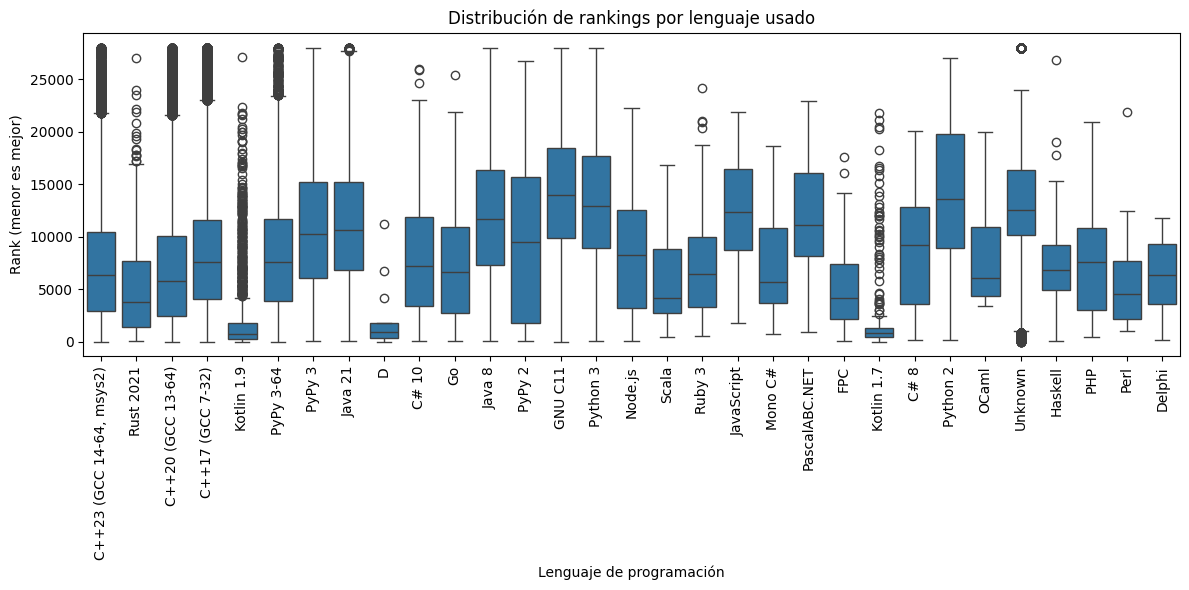

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_standings, x='languageUsed', y='rank')
plt.xticks(rotation=90)
plt.title("Distribución de rankings por lenguaje usado")
plt.ylabel("Rank (menor es mejor)")
plt.xlabel("Lenguaje de programación")
plt.tight_layout()
plt.show()


Un boxplot de la distribucion de rankings por lenguaje usado. Podemos observar que C++20, Rust 2021, y varias versiones de C++ tienen medianas bajas y distribuciones más concentradas en buenos puestos.Mientras que Python 2, Delphi, Perl, y PascalABC.NET tienen medianas más altas, lo que sugiere que los usuarios de estos lenguajes tienden a obtener peores posiciones.

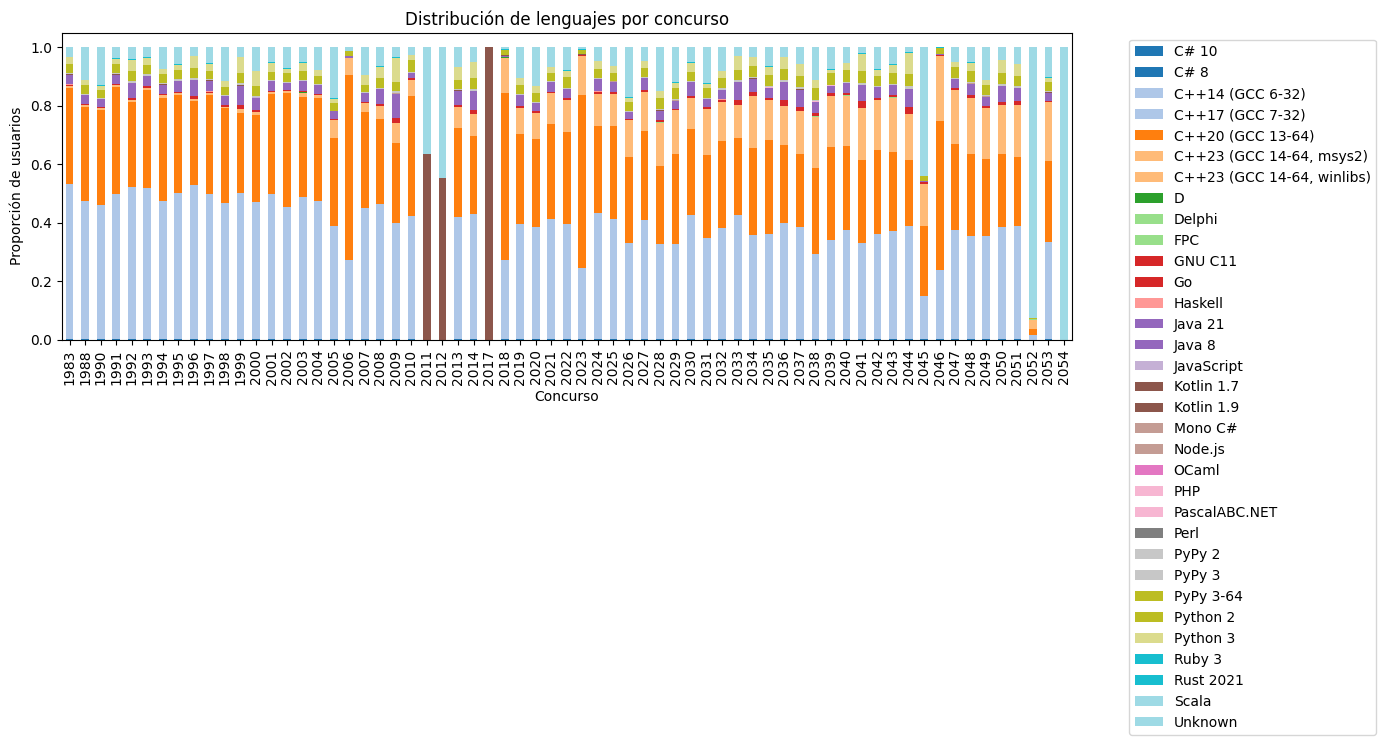

In [32]:
lang_by_contest = df_standings.groupby(['contestId', 'languageUsed']).size().unstack(fill_value=0)
lang_by_contest = lang_by_contest.div(lang_by_contest.sum(axis=1), axis=0)  # proporciones

lang_by_contest.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
plt.title("Distribución de lenguajes por concurso")
plt.ylabel("Proporción de usuarios")
plt.xlabel("Concurso")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Aqui podemos ver la distribucion de lenguajes en concursos. Observamos que C++20,17 y 14 son los mas usados en general en los concursos. Tambien vemos que en el concurso 2017 solo se uso Koitlin, pero eso se puede explicar ya que ese concurso era una final en la que solo participo 1 persona.

C:\Users\Fabian\AppData\Local\Temp\ipykernel_44388\2248983748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rank', y='points', data=df_standings, palette="Set2")


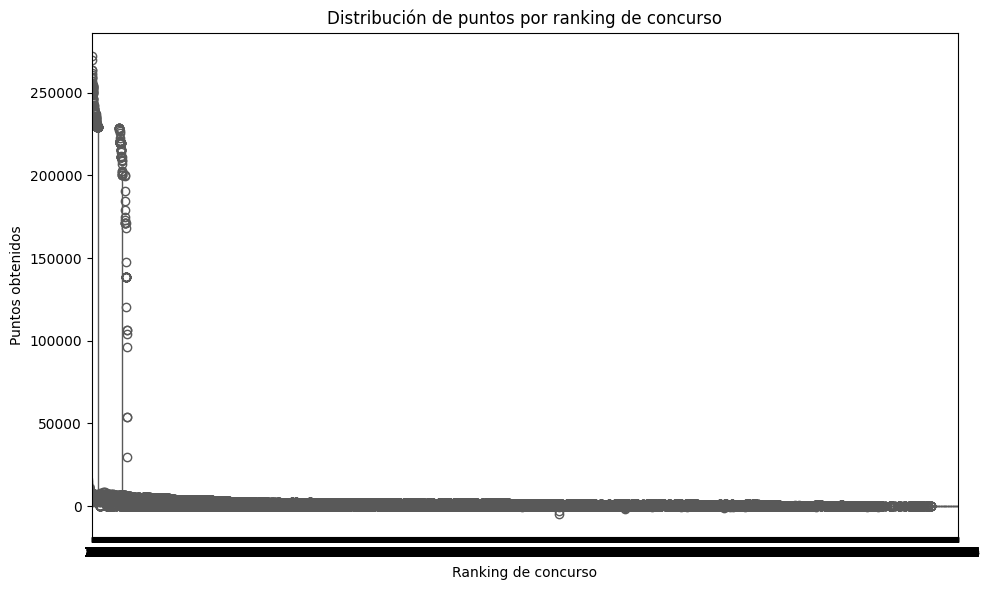

In [45]:
plt.figure(figsize=(10,6))
sns.boxplot(x='rank', y='points', data=df_standings, palette="Set2")
plt.title("Distribución de puntos por ranking de concurso")
plt.xlabel("Ranking de concurso")
plt.ylabel("Puntos obtenidos")
plt.tight_layout()
plt.show()


El grafico de dispersion nos dice que la relación entre puntos y ranking es altamente no lineal y decreciente ya que los mejores clasificados ganan desproporcionadamente más puntos. Posiblemente el sistema de puntuación de Codeforces  favorece mucho mas a quienes logran resolver más problemas en menos tiempo, y penaliza rápidamente a los demás.

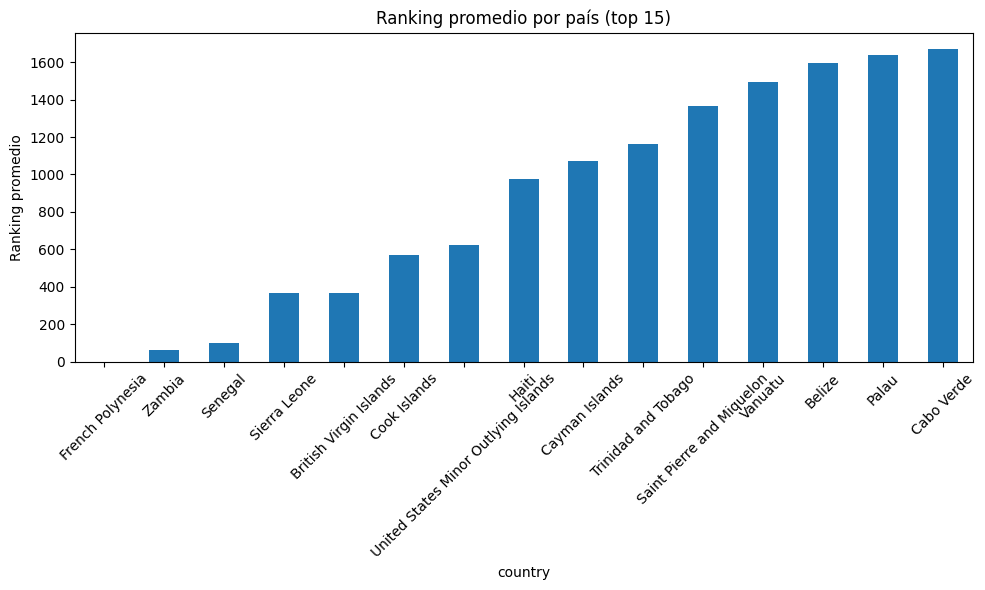

In [19]:
if 'country' in df_standings.columns:
    avg_rank_by_country = df_standings.groupby('country')['rank'].mean().sort_values().head(15)
    plt.figure(figsize=(10, 6))
    avg_rank_by_country.plot(kind='bar')
    plt.title("Ranking promedio por país (top 15)")
    plt.ylabel("Ranking promedio")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


En este simple grafico vemos que el promedio de ranking es mayor en Cabo Verde, lo cual indica que es el pais con peor desempeño en Codeforces

C:\Users\Fabian\AppData\Local\Temp\ipykernel_44388\1267999719.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Spectral')


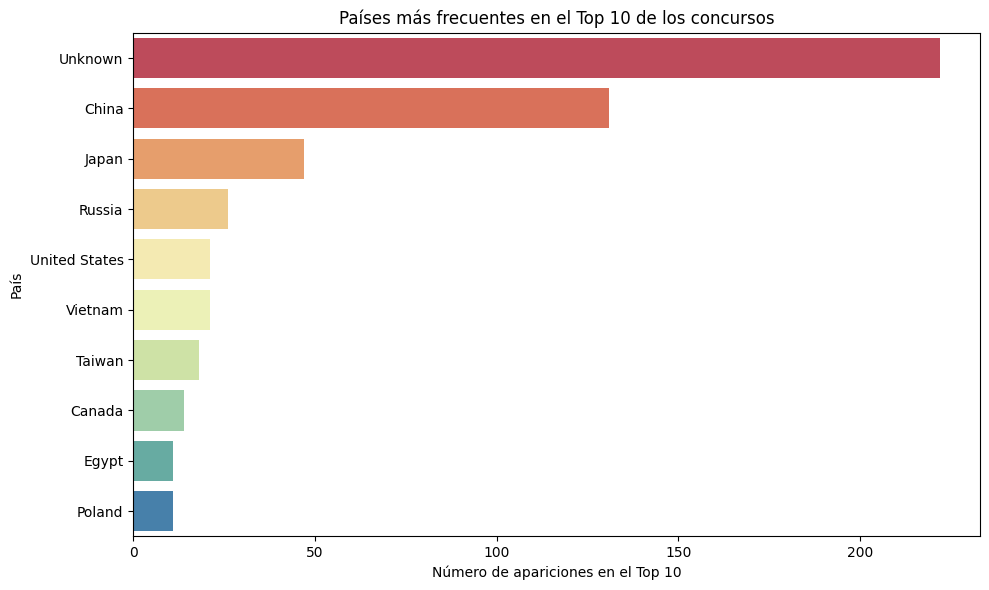

In [47]:
# Filtrar solo los top 10 de cada concurso
top_10_df = df_standings[df_standings['rank'] <= 10]

# Contar cuántas veces aparece cada país en el top 10
top_countries = top_10_df['country'].value_counts().head(10)

# Graficar
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Spectral')
plt.title("Países más frecuentes en el Top 10 de los concursos")
plt.xlabel("Número de apariciones en el Top 10")
plt.ylabel("País")
plt.tight_layout()
plt.show()


Por ultimo vemos que China es el pais que mas ha aparecido en el top 10 de cada concurso, seguido por Japon y Russia. Siendo el numero de "Unknown" tan grande es dificil saber cuantos de ellos pertenecen a que pais, pero por lo que se ve podriamos suponer que pertenecen a los 3 primeros paises, solo que no quisieron identificarse.